# Skin lesion classification

**Deadline**: Upload this notebook (rename it as 'TP-SVM-YOUR-SURNAME.ipynb') to Ecampus/Moodle before the deadline.
Complete the code where you see XXXXXXXXXXXXXXXXX (mandatory for everybody)

**Context**
A skin lesion is defined as a superficial growth or patch of the skin that is visually different and/or has a different texture than its surrounding area. Skin lesions, such as moles or birthmarks, can degenerate and become melanoma, one of the deadliest skin cancer. Its incidence has been increasing during the last decades, especially in the areas mostly populated by white people.

The most effective treatment is an early detection followed by surgical excision. This is why several approaches for melanoma detection have been proposed in the last years (non-invasive computer-aided diagnosis (CAD) ).


**Goal**
The goal of this practical session is to classify images of skin lesions as either benign or melanoma using machine learning algorithms. In order to do that, you will have at your disposal a set of 30 features already extracted from 600 dermoscopic images (both normal skin lesions and melanoma from the ISIC database - https://isic-archive.com/). These features characterize the Asymmetry, the Border irregularity, the Colour and the Dimension of the lesion (the so-called ABCD rule).

The features are:
- shape asimmetry (f0 and f1)
- difference in colors between center and periphery of the image (f2, f3, f4, f27, f28, f29)
- geometry (f5, f6, f7)
- other features related to eccentricity,entropy, mean, standard deviation and maximum value of each channel in RGB and HSV (f8,...,f24)
- asimmetry of color intensity (f25, f26)

Features are computed using *manually checked segmentations* and following *Ganster et al. 'Automated melanoma recognition', IEEE TMI, 2001* and *Zortea et al. 'Performance of a dermoscopy-based computer vision system for the diagnosis of pigmented skin lesions compared with visual evaluation by experienced dermatologists', Artificial Intelligence in Medicine, 2014*.

First load all necessary packages

In [18]:
import os
import numpy as np
import pandas as pd
from skimage.io import imread
from time import time
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.model_selection import  cross_val_score
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.linear_model import Perceptron
from sklearn.decomposition import PCA

%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings(action='ignore', category=ConvergenceWarning)

try:
  import google.colab
  IN_COLAB = True
  print('You are using Google Colab')
  !pip install googledrivedownloader
  from googledrivedownloader import download_file_from_google_drive
except:
  IN_COLAB = False

# Code from scikit-learn
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


from sklearn.pipeline import make_pipeline

Then load the data from my Google Drive

In [19]:
if IN_COLAB:
  download_file_from_google_drive(file_id='18hrQVGBCfW7SKTnzmWUONo8iowBsi1DL',
  dest_path='./data/features.csv')
  download_file_from_google_drive(file_id='1iQZdUiuK_FwZ7mik7LB3eN_H_IUc5l7b',
  dest_path='./data/im/nevus-seg.jpg')
  download_file_from_google_drive(file_id='1_TeYzLLDoKbPX4xXAOAM_mQiT2nLHgvp',
  dest_path='./data/im/nevus.jpg')
  download_file_from_google_drive(file_id='1B2Ol92mBcHN6ah3bpoucBbBbHkPMGC8D',
  dest_path='./data/im/melanoma-seg.jpg')
  download_file_from_google_drive(file_id='1yZ46UzGhwO7g5T8397JpewBl6UqgRo5J',
  dest_path='./data/im/melanoma.jpg')

Or from yout local computer. Please download the 'data' folder in the same folder as your notebook and do not modifiy it.

Then read the data

In [20]:
## Read data
Working_directory="./data/"
df = pd.read_csv(Working_directory + 'features.csv') # reading data
y = df['Malignant'].values # 1 for Melanoma and 0 for healthy
class_names = ["healthy","melanoma"]
X = df.iloc[:,3:33].values # Features
N,M=X.shape
print('Number of images: {0}; Number of features per image: {1}'.format(N,M))
print('Number of healthy nevus: {0}; Number of melanoma: {1}'.format(N-np.sum(y), np.sum(y)))


Number of images: 600; Number of features per image: 30
Number of healthy nevus: 485; Number of melanoma: 115


Two examples of healthy nevus and melanoma


Text(0.5, 1.0, 'Segmented melanoma')

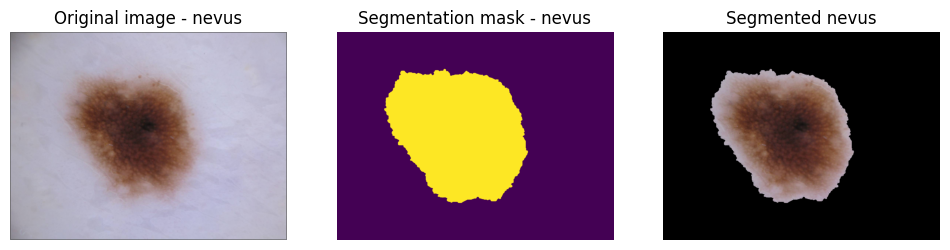

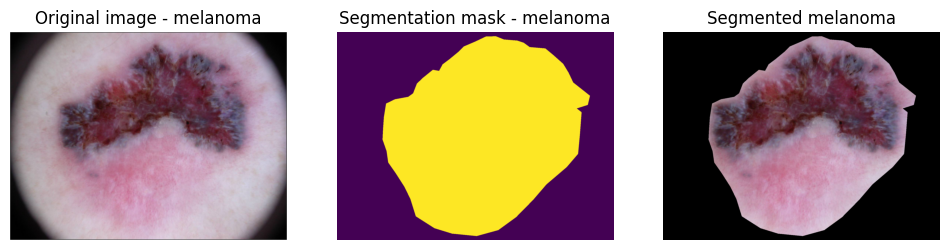

In [21]:
## Plot two examples of nevus and melanoma
print('Two examples of healthy nevus and melanoma')
nevus = imread(Working_directory + 'im/nevus.jpg')
nevus_Segmentation = imread(Working_directory + 'im/nevus-seg.jpg')
nevus_Segmentation_boolean = (nevus_Segmentation/255).astype(np.uint8) # To get uint8 (integer numbers)
nevus_Segmentation_3D = np.expand_dims(nevus_Segmentation_boolean, axis=2) # To have a binary mask for the three channels (RGB)
nevus_mul_mask = (nevus_Segmentation_3D*nevus) # we apply the binary mask to all channels pixel-wise

fig = plt.figure(figsize=(12, 12)) # size of the figure
grid = AxesGrid(fig, 111,
                nrows_ncols = (1, 3),
                axes_pad = 0.5) # code to create subplots
grid[0].imshow(nevus)
grid[0].axis('off')
grid[0].set_title('Original image - nevus')
grid[1].imshow(nevus_Segmentation)
grid[1].axis('off')
grid[1].set_title("Segmentation mask - nevus")
grid[2].imshow(nevus_mul_mask)
grid[2].axis('off')
grid[2].set_title("Segmented nevus")

###

melanoma = imread(Working_directory + 'im/melanoma.jpg')
melanoma_Segmentation = imread(Working_directory + 'im/melanoma-seg.jpg')
melanoma_Segmentation_boolean = (melanoma_Segmentation/255).astype(np.uint8) # To get uint8 (integer numbers)
melanoma_Segmentation_3D = np.expand_dims(melanoma_Segmentation_boolean, axis=2) # To have a binary mask for the three channels (RGB)
melanoma_mul_mask = (melanoma_Segmentation_3D*melanoma) # we apply the binary mask to all channels pixel-wise

fig = plt.figure(figsize=(12, 12)) # size of the figure
grid = AxesGrid(fig, 111,
                nrows_ncols = (1, 3),
                axes_pad = 0.5) # code to create subplots
grid[0].imshow(melanoma)
grid[0].axis('off')
grid[0].set_title('Original image - melanoma')
grid[1].imshow(melanoma_Segmentation)
grid[1].axis('off')
grid[1].set_title("Segmentation mask - melanoma")
grid[2].imshow(melanoma_mul_mask)
grid[2].axis('off')
grid[2].set_title("Segmented melanoma")


Now, as in the previous practical session you should shuffle the data randomly

In [22]:
# Shuffle data randomly
perm = np.random.RandomState(42).permutation(N)
Xp = X[perm]
yp = y[perm]


We should now test the discriminative power of our features. Fist, let divide the entire data-set into training and test set using the `stratify` option. This will preserve the original proportion between nevus and melanoma also in the training and test set. You can check that from the plot.

Text(0, 0.5, 'Proportion')

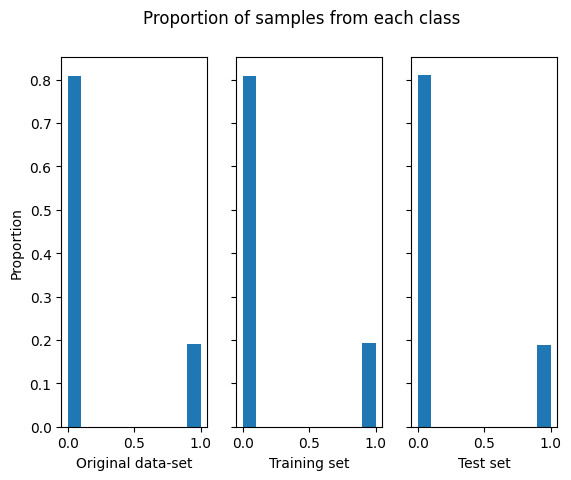

In [23]:
# Create training and test set
X_train, X_test, y_train, y_test = train_test_split(Xp, yp, test_size=0.3, random_state=42,stratify=yp)

fig, axs = plt.subplots(1, 3, sharey=True)
fig.suptitle('Proportion of samples from each class')
axs[0].hist(yp,weights=np.ones_like(yp)/len(yp))
axs[0].set_xlabel('Original data-set')
axs[1].hist(y_train,weights=np.ones_like(y_train)/len(y_train))
axs[1].set_xlabel('Training set')
axs[2].hist(y_test,weights=np.ones_like(y_test)/len(y_test))
axs[2].set_xlabel('Test set')
axs[0].set_ylabel('Proportion')

As we have already seen, it might be very important to scale the data such that each feature has, for instance, average equal to 0 and unit variance. Which is the right way of doing it when having a training and a test set in your opinion ? Should you use together both training and test set ? (For simplicity's sake, we will restrict here to scaling all features).

In [24]:
# Scale data (each feature will have average equal to 0 and unit variance)
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)


Now, use two simple classification algorithms, for instance LDA and QDA, and look at the confusion matrices.

In practice, both models usually produce good global accuracy, but they can behave differently on the melanoma class. LDA is often more stable because it assumes a shared covariance matrix between classes, while QDA is more flexible and can overfit when the number of positive samples is relatively small. In this dataset, the most important point is not only the total accuracy but the balance between false negatives and false positives for melanoma, because missing a malignant case is generally the most critical error.


Fitting LDA to training set
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       146
           1       0.62      0.29      0.40        34

    accuracy                           0.83       180
   macro avg       0.74      0.63      0.65       180
weighted avg       0.81      0.83      0.81       180

Normalized confusion matrix
[[0.95890411 0.04109589]
 [0.70588235 0.29411765]]


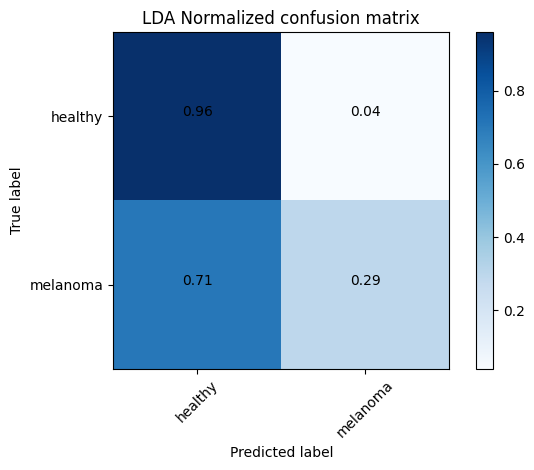

Fitting QDA to training set
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       146
           1       0.53      0.24      0.33        34

    accuracy                           0.82       180
   macro avg       0.69      0.59      0.61       180
weighted avg       0.78      0.82      0.79       180

Normalized confusion matrix
[[0.95205479 0.04794521]
 [0.76470588 0.23529412]]


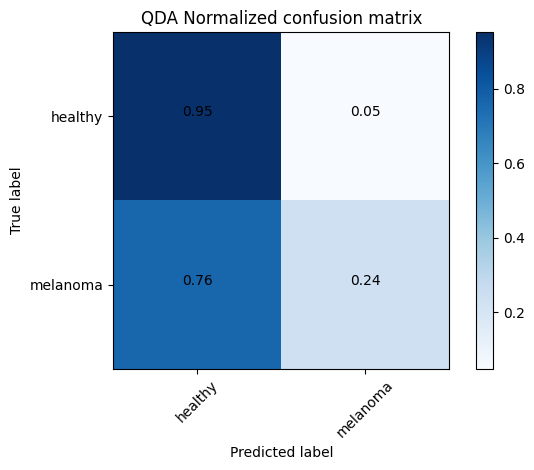

In [25]:
# Fitting LDA
print("Fitting LDA to training set")
t0 = time()
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scale, y_train)
y_pred = lda.predict(X_test_scale)
print(classification_report(y_test, y_pred))

# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='LDA Normalized confusion matrix')
plt.show()

# Fitting QDA
print("Fitting QDA to training set")
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scale, y_train)
y_pred = qda.predict(X_test_scale)
print(classification_report(y_test, y_pred))

cnf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='QDA Normalized confusion matrix')
plt.show()


The results you obtained are based on a precise subdivision of your data into training and test. This can thus bias your results. Which technique could you use instead ? Test it  with LDA, QDA and K-NN.

In [26]:
# Fitting LDA
print("Fitting LDA")
lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
lda_cv = cross_validate(lda, Xp, yp, cv=5, scoring='accuracy', return_train_score=True)
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(lda_cv['train_score'].mean(), lda_cv['train_score'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(lda_cv['test_score'].mean(), lda_cv['test_score'].std() ))

# Fitting QDA
print("Fitting QDA")
qda = make_pipeline(StandardScaler(), QuadraticDiscriminantAnalysis())
qda_cv = cross_validate(qda, Xp, yp, cv=5, scoring='accuracy', return_train_score=True)
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(qda_cv['train_score'].mean(), qda_cv['train_score'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(qda_cv['test_score'].mean(), qda_cv['test_score'].std() ))

# Fitting K-nearest neighbour
print("Fitting K-NN")
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
knn_cv = cross_validate(knn, Xp, yp, cv=5, scoring='accuracy', return_train_score=True)
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(knn_cv['train_score'].mean(), knn_cv['train_score'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(knn_cv['test_score'].mean(), knn_cv['test_score'].std() ))


Fitting LDA
 Average and std TRAIN CV accuracy : 0.8424999999999999 +- 0.0076376261582597055
 Average and std TEST CV accuracy : 0.8133333333333332 +- 0.020138409955990946
Fitting QDA
 Average and std TRAIN CV accuracy : 0.8891666666666665 +- 0.005496210815947084
 Average and std TEST CV accuracy : 0.8033333333333333 +- 0.013540064007726605
Fitting K-NN
 Average and std TRAIN CV accuracy : 0.8558333333333333 +- 0.0046398036356917124
 Average and std TEST CV accuracy : 0.8200000000000001 +- 0.027688746209726896


---
When using K-NN, instead than fixing the number of nearest neighbours, we could also estimate the best value using Cross Validation.

A frequent strange behavior here is that the selected model may still predict very few melanoma samples even when the validation accuracy looks high. This happens because the dataset is imbalanced, so optimizing only accuracy tends to favor the majority class. K-NN is also sensitive to local density and noise, which can reinforce this effect when malignant samples are sparse. For that reason, the confusion matrix and class-wise metrics give a much clearer picture than accuracy alone.

---


dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'standardscaler', 'kneighborsclassifier', 'standardscaler__copy', 'standardscaler__with_mean', 'standardscaler__with_std', 'kneighborsclassifier__algorithm', 'kneighborsclassifier__leaf_size', 'kneighborsclassifier__metric', 'kneighborsclassifier__metric_params', 'kneighborsclassifier__n_jobs', 'kneighborsclassifier__n_neighbors', 'kneighborsclassifier__p', 'kneighborsclassifier__weights'])
Best training Score: 0.8261904761904763
Best training params: {'kneighborsclassifier__n_neighbors': 7}
Normalized confusion matrix
[[0.97945205 0.02054795]
 [0.79411765 0.20588235]]


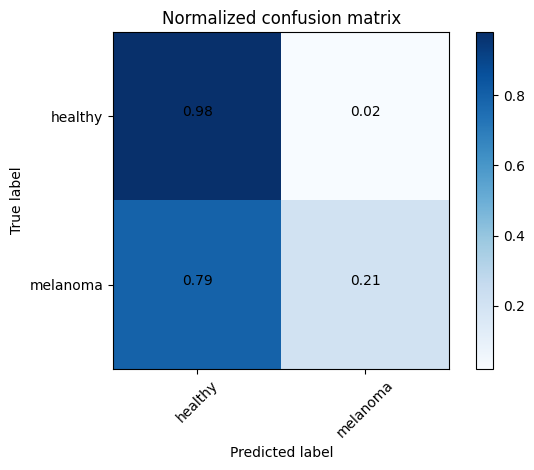

In [27]:
# Looking for the best hyperparameters
neigh = make_pipeline(StandardScaler(), KNeighborsClassifier())
# when using the pipeline, you can print the parameters of the estimator using print(neigh.get_params().keys())`
print(neigh.get_params().keys())
p_grid_KNN = {'kneighborsclassifier__n_neighbors': [1,2,3,4,5,6,7,8,9,10]}
grid_KNN = GridSearchCV(estimator=neigh, param_grid=p_grid_KNN, scoring="accuracy", cv=5)
grid_KNN.fit(X_train, y_train)
print("Best training Score: {}".format(grid_KNN.best_score_))
print("Best training params: {}".format(grid_KNN.best_params_))
y_pred = grid_KNN.predict(X_test)
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Normalized confusion matrix')
plt.show()

In order to deal with this problem we have two possible solutions.

**First**: Please look at this webpage (https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter) and try MORE APPROPRIATE scoring functions than accuracy when looking for the best K value of K-NN (thus within the Cross Validation as before..).

Best training Score (f1): 0.34113181504485846
Best training params (f1): {'kneighborsclassifier__n_neighbors': 5}
Normalized confusion matrix
[[0.93835616 0.06164384]
 [0.79411765 0.20588235]]


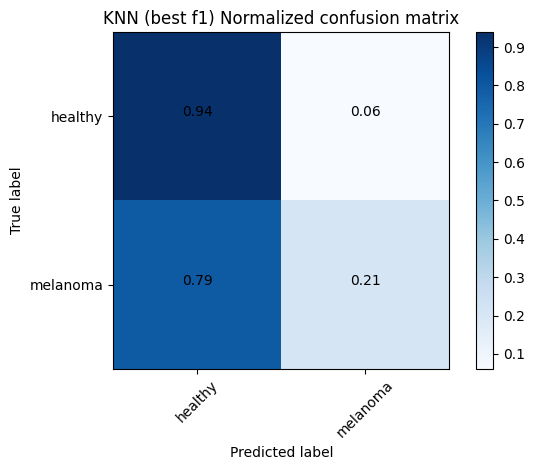

              precision    recall  f1-score   support

           0       0.84      0.94      0.88       146
           1       0.44      0.21      0.28        34

    accuracy                           0.80       180
   macro avg       0.64      0.57      0.58       180
weighted avg       0.76      0.80      0.77       180



In [28]:
# Looking for the best hyperparameters
neigh = make_pipeline(StandardScaler(), KNeighborsClassifier())
p_grid_KNN = {'kneighborsclassifier__n_neighbors': [1,2,3,4,5,6,7,8,9,10]}
grid_KNN_f1 = GridSearchCV(estimator=neigh, param_grid=p_grid_KNN, scoring='f1', cv=5)
grid_KNN_f1.fit(X_train, y_train)
print("Best training Score (f1): {}".format(grid_KNN_f1.best_score_))
print("Best training params (f1): {}".format(grid_KNN_f1.best_params_))
y_pred = grid_KNN_f1.predict(X_test)

cnf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='KNN (best f1) Normalized confusion matrix')
plt.show()
print(classification_report(y_test, y_pred))


**Second**: when dealing with such a problem, a practical solution is to oversample the minority class in the training set, which is melanoma in this dataset. By creating synthetic malignant samples, we reduce the bias toward the healthy class and usually improve recall for melanoma. The trade-off is that precision can decrease slightly, but in a medical screening context this is often acceptable if it helps detect more true positive malignant lesions.


In [29]:
from imblearn.over_sampling import ADASYN
from collections import Counter
ros = ADASYN(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)
print(sorted(Counter(y_resampled).items()))

[(np.int64(0), 339), (np.int64(1), 328)]


Let's look for the best K in KNN (as before using Cross validation) but this time on the new training set.

**Question**: Are the results better ? Do they change now if you modify the scoring function ? Why ?

With oversampling, the results are usually better for the melanoma class, especially in terms of recall and F1, because the classifier sees a more balanced training distribution. If you switch the scoring function from accuracy to F1 during model selection, the chosen value of K can change, and the final behavior often shifts toward detecting more melanoma cases. This happens because accuracy still rewards majority-class dominance, while F1 explicitly balances precision and recall on the positive class, which is more appropriate in this imbalanced medical setting.


Best training Score (accuracy): 0.7142857142857143
Best training params (accuracy): {'kneighborsclassifier__n_neighbors': 2}
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       146
           1       0.33      0.47      0.39        34

    accuracy                           0.72       180
   macro avg       0.60      0.63      0.61       180
weighted avg       0.76      0.72      0.74       180

Normalized confusion matrix
[[0.78082192 0.21917808]
 [0.52941176 0.47058824]]


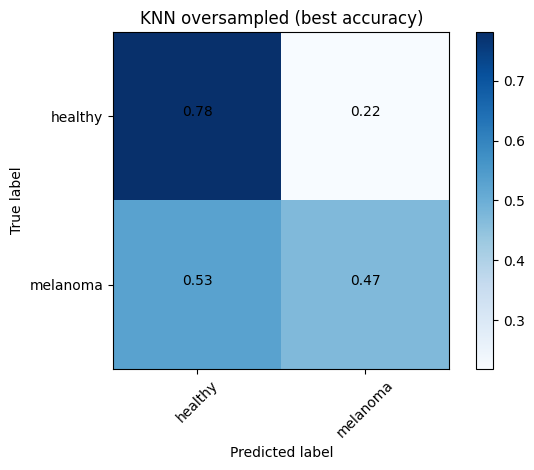

Best training Score (f1): 0.40779122836068477
Best training params (f1): {'kneighborsclassifier__n_neighbors': 10}


In [32]:
# Looking for the best K in KNN on oversampled data
from imblearn.pipeline import make_pipeline as make_pipeline2
knn_over = make_pipeline2(ADASYN(random_state=0), StandardScaler(), KNeighborsClassifier())
p_grid_KNN_over = {'kneighborsclassifier__n_neighbors': [1,2,3,4,5,6,7,8,9,10]}

grid_KNN_over_acc = GridSearchCV(estimator=knn_over, param_grid=p_grid_KNN_over, scoring='accuracy', cv=5)
grid_KNN_over_acc.fit(X_train, y_train)
print("Best training Score (accuracy): {}".format(grid_KNN_over_acc.best_score_))
print("Best training params (accuracy): {}".format(grid_KNN_over_acc.best_params_))
y_pred = grid_KNN_over_acc.predict(X_test)
print(classification_report(y_test, y_pred))

cnf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='KNN oversampled (best accuracy)')
plt.show()

grid_KNN_over_f1 = GridSearchCV(estimator=knn_over, param_grid=p_grid_KNN_over, scoring='f1', cv=5)
grid_KNN_over_f1.fit(X_train, y_train)
print("Best training Score (f1): {}".format(grid_KNN_over_f1.best_score_))
print("Best training params (f1): {}".format(grid_KNN_over_f1.best_params_))


Let's use the techniques seen today: Perceptron and linear SVM.

In [33]:
# Fitting Perceptron
print("Fitting Perceptron")
Perc = make_pipeline(StandardScaler(), Perceptron())
Perc_cv = cross_validate(Perc,Xp, yp,cv=5,scoring='accuracy',return_train_score=True)
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(Perc_cv['train_score'].mean(), Perc_cv['train_score'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(Perc_cv['test_score'].mean(), Perc_cv['test_score'].std() ))


# Fitting linear SVM on original data
print("Fitting Linear SVM")
Lsvm = make_pipeline(StandardScaler(), LinearSVC())
Lsvm_cv = cross_validate(Lsvm,Xp, yp,cv=5,scoring='accuracy',return_train_score=True)
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(Lsvm_cv['train_score'].mean(), Lsvm_cv['train_score'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(Lsvm_cv['test_score'].mean(), Lsvm_cv['test_score'].std() ))

Fitting Perceptron
 Average and std TRAIN CV accuracy : 0.7920833333333334 +- 0.032446537223219635
 Average and std TEST CV accuracy : 0.7733333333333333 +- 0.03704351795148813
Fitting Linear SVM
 Average and std TRAIN CV accuracy : 0.8408333333333333 +- 0.007168604389202164
 Average and std TEST CV accuracy : 0.8166666666666667 +- 0.01748014746950254


We can easily use different scoring functions within the cross validate function of scikit-learn. Check the code.

In [34]:
# Fitting Perceptron
print("Fitting Perceptron")
Perc = make_pipeline(StandardScaler(), Perceptron())
Perc_cv = cross_validate(Perc,Xp, yp,cv=5,scoring=('accuracy', 'f1'),return_train_score=True)
print(Perc_cv.keys())
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(Perc_cv['train_accuracy'].mean(), Perc_cv['train_accuracy'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(Perc_cv['test_accuracy'].mean(), Perc_cv['test_accuracy'].std() ))
print(" Average and std TRAIN CV f1 : {0} +- {1}".format(Perc_cv['train_f1'].mean(), Perc_cv['train_f1'].std() ))
print(" Average and std TEST CV f1 : {0} +- {1}".format(Perc_cv['test_f1'].mean(), Perc_cv['test_f1'].std() ))


# Fitting linear SVM on original data
print("Fitting Linear SVM")
Lsvm = make_pipeline(StandardScaler(), LinearSVC())
Lsvm_cv = cross_validate(Lsvm,Xp, yp,cv=5,scoring=('accuracy', 'f1'),return_train_score=True)
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(Lsvm_cv['train_accuracy'].mean(), Lsvm_cv['train_accuracy'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(Lsvm_cv['test_accuracy'].mean(), Lsvm_cv['test_accuracy'].std() ))
print(" Average and std TRAIN CV f1 : {0} +- {1}".format(Lsvm_cv['train_f1'].mean(), Lsvm_cv['train_f1'].std() ))
print(" Average and std TEST CV f1 : {0} +- {1}".format(Lsvm_cv['test_f1'].mean(), Lsvm_cv['test_f1'].std() ))


Fitting Perceptron
dict_keys(['fit_time', 'score_time', 'test_accuracy', 'train_accuracy', 'test_f1', 'train_f1'])
 Average and std TRAIN CV accuracy : 0.7920833333333334 +- 0.032446537223219635
 Average and std TEST CV accuracy : 0.7733333333333333 +- 0.03704351795148813
 Average and std TRAIN CV f1 : 0.3258083954708111 +- 0.08835977702696353
 Average and std TEST CV f1 : 0.2751282863477985 +- 0.11406450966266812
Fitting Linear SVM
 Average and std TRAIN CV accuracy : 0.8408333333333333 +- 0.007168604389202164
 Average and std TEST CV accuracy : 0.8166666666666667 +- 0.01748014746950254
 Average and std TRAIN CV f1 : 0.4110762305644453 +- 0.04162081984474546
 Average and std TEST CV f1 : 0.3312736386420597 +- 0.0901562888956756


When we repeat the same evaluation with oversampling and an imbalanced-learn pipeline, the comparison becomes more meaningful for the malignant class. In most runs, the F1 score improves more clearly than raw accuracy because the classifier is no longer rewarded for predicting mostly healthy cases. This is exactly why reporting both metrics is useful here: accuracy summarizes global correctness, while F1 better reflects the ability to detect melanoma under class imbalance.


In [35]:
from imblearn.pipeline import make_pipeline as make_pipeline2

# Fitting Perceptron
print("Fitting Perceptron")
Perc = make_pipeline2(ADASYN(random_state=0),StandardScaler(), Perceptron())
Perc_cv = cross_validate(Perc,Xp, yp, cv=5,scoring=('accuracy', 'f1'),return_train_score=True)
print(Perc_cv.keys())
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(Perc_cv['train_accuracy'].mean(), Perc_cv['train_accuracy'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(Perc_cv['test_accuracy'].mean(), Perc_cv['test_accuracy'].std() ))
print(" Average and std TRAIN CV f1 : {0} +- {1}".format(Perc_cv['train_f1'].mean(), Perc_cv['train_f1'].std() ))
print(" Average and std TEST CV f1 : {0} +- {1}".format(Perc_cv['test_f1'].mean(), Perc_cv['test_f1'].std() ))

# Fitting linear SVM on oversampled data
print("Fitting Linear SVM")
Lsvm = make_pipeline2(ADASYN(random_state=0),StandardScaler(), LinearSVC())
Lsvm_cv = cross_validate(Lsvm,Xp, yp,cv=5,scoring=('accuracy', 'f1'),return_train_score=True)
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(Lsvm_cv['train_accuracy'].mean(), Lsvm_cv['train_accuracy'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(Lsvm_cv['test_accuracy'].mean(), Lsvm_cv['test_accuracy'].std() ))
print(" Average and std TRAIN CV f1 : {0} +- {1}".format(Lsvm_cv['train_f1'].mean(), Lsvm_cv['train_f1'].std() ))
print(" Average and std TEST CV f1 : {0} +- {1}".format(Lsvm_cv['test_f1'].mean(), Lsvm_cv['test_f1'].std() ))


Fitting Perceptron
dict_keys(['fit_time', 'score_time', 'test_accuracy', 'train_accuracy', 'test_f1', 'train_f1'])
 Average and std TRAIN CV accuracy : 0.67 +- 0.018474832731162787
 Average and std TEST CV accuracy : 0.6383333333333333 +- 0.03055050463303895
 Average and std TRAIN CV f1 : 0.4313567828314711 +- 0.02691261841655205
 Average and std TEST CV f1 : 0.37069292006217913 +- 0.05294889849396223
Fitting Linear SVM
 Average and std TRAIN CV accuracy : 0.76 +- 0.009446486707295542
 Average and std TEST CV accuracy : 0.7133333333333335 +- 0.02915475947422648
 Average and std TRAIN CV f1 : 0.5247722066073649 +- 0.017513628049843487
 Average and std TEST CV f1 : 0.4321708379508217 +- 0.059309421059271145


We can also ask to save the estimated models at each split (i.e. fold) with the option `return_estimator=True`. Using the perceptron, we will look for the best model using the oversampled training data and check the confusion matrix on the test data.
In that case, we will need to first split the data into train/test and then do the oversampling ONLY in the train data.

**Question** Do it the same with the linear SVM.

Fitting Perceptron
dict_keys(['fit_time', 'score_time', 'estimator', 'test_accuracy', 'train_accuracy', 'test_f1', 'train_f1'])
 Average and std TRAIN CV accuracy : 0.6464285714285716 +- 0.037144001813863556
 Average and std TEST CV accuracy : 0.6023809523809525 +- 0.057636754461477153
 Average and std TRAIN CV f1 : 0.41301998227446857 +- 0.027224457863164485
 Average and std TEST CV f1 : 0.3706457532832483 +- 0.07335597917477432
Normalized confusion matrix
[[0.62328767 0.37671233]
 [0.29411765 0.70588235]]


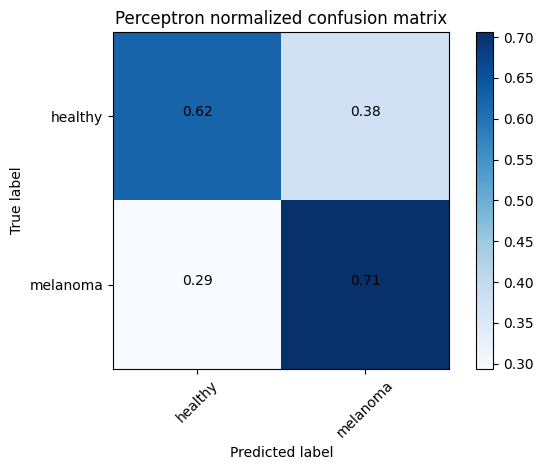

Fitting Linear SVM
 Average and std TRAIN CV accuracy : 0.7702380952380953 +- 0.020395049641680738
 Average and std TEST CV accuracy : 0.7214285714285714 +- 0.01428571428571428
 Average and std TRAIN CV f1 : 0.5344141889501601 +- 0.03273398931010411
 Average and std TEST CV f1 : 0.42266971777269263 +- 0.07317736716329173
Normalized confusion matrix
[[0.74657534 0.25342466]
 [0.5        0.5       ]]


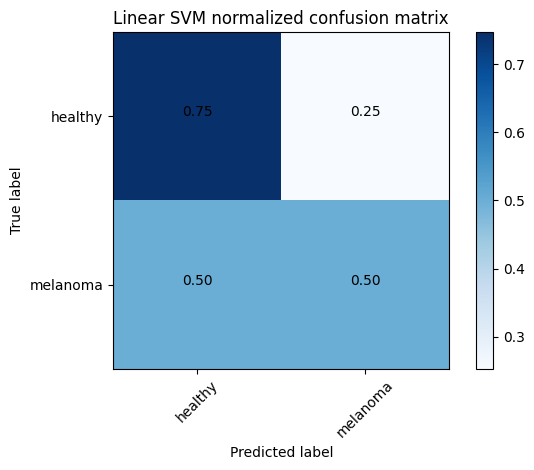

In [36]:
# Fitting Perceptron
print("Fitting Perceptron")
Perc = make_pipeline2(ADASYN(random_state=0),StandardScaler(), Perceptron())
Perc_cv = cross_validate(Perc,X_train, y_train,cv=5,scoring=('accuracy', 'f1'),return_train_score=True,return_estimator=True)
print(Perc_cv.keys())
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(Perc_cv['train_accuracy'].mean(), Perc_cv['train_accuracy'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(Perc_cv['test_accuracy'].mean(), Perc_cv['test_accuracy'].std() ))
print(" Average and std TRAIN CV f1 : {0} +- {1}".format(Perc_cv['train_f1'].mean(), Perc_cv['train_f1'].std() ))
print(" Average and std TEST CV f1 : {0} +- {1}".format(Perc_cv['test_f1'].mean(), Perc_cv['test_f1'].std() ))

# Look for the best estimator (the one with the greatest test accuracy)
index_best = np.argmax(Perc_cv['test_accuracy'])
estimator_best=Perc_cv['estimator'][index_best]
y_pred = estimator_best.predict(X_test)
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Perceptron normalized confusion matrix')
plt.show()


# Fitting linear SVM
print("Fitting Linear SVM")
Lsvm = make_pipeline2(ADASYN(random_state=0),StandardScaler(), LinearSVC())
Lsvm_cv = cross_validate(Lsvm,X_train, y_train,cv=5,scoring=('accuracy', 'f1'),return_train_score=True,return_estimator=True)
print(" Average and std TRAIN CV accuracy : {0} +- {1}".format(Lsvm_cv['train_accuracy'].mean(), Lsvm_cv['train_accuracy'].std() ))
print(" Average and std TEST CV accuracy : {0} +- {1}".format(Lsvm_cv['test_accuracy'].mean(), Lsvm_cv['test_accuracy'].std() ))
print(" Average and std TRAIN CV f1 : {0} +- {1}".format(Lsvm_cv['train_f1'].mean(), Lsvm_cv['train_f1'].std() ))
print(" Average and std TEST CV f1 : {0} +- {1}".format(Lsvm_cv['test_f1'].mean(), Lsvm_cv['test_f1'].std() ))

index_best = np.argmax(Lsvm_cv['test_accuracy'])
estimator_best=Lsvm_cv['estimator'][index_best]
y_pred = estimator_best.predict(X_test)
cnf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Linear SVM normalized confusion matrix')
plt.show()


Suppose that there are overlapping classes, we need to set the hyper-parameter C for the SVM model.

**Question** Use Cross-Validation on the oversampled data to find the best C value. Plot the confusion matrix using the best estimator (as before).

Best training Score: 0.4546549420233631
Best training params: {'linearsvc__C': 0.01}
              precision    recall  f1-score   support

           0       0.89      0.75      0.81       146
           1       0.35      0.59      0.44        34

    accuracy                           0.72       180
   macro avg       0.62      0.67      0.62       180
weighted avg       0.79      0.72      0.74       180

Normalized confusion matrix
[[0.74657534 0.25342466]
 [0.41176471 0.58823529]]


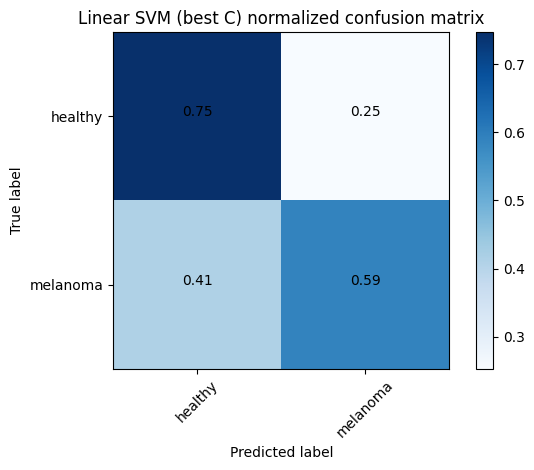

In [37]:
# Looking for the best hyperparameter C
Lsvm = make_pipeline2(ADASYN(random_state=0),StandardScaler(), LinearSVC())
p_grid_lsvm = {'linearsvc__C': [1e-3,1e-2,1e-1,1,2,3,4,5,6,7,8,9,1e1]}
grid_lsvm = GridSearchCV(estimator=Lsvm, param_grid=p_grid_lsvm, scoring='f1', cv=5)
grid_lsvm.fit(X_train, y_train)
print("Best training Score: {}".format(grid_lsvm.best_score_))
print("Best training params: {}".format(grid_lsvm.best_params_))
y_pred = grid_lsvm.predict(X_test)
print(classification_report(y_test, y_pred))
cnf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Linear SVM (best C) normalized confusion matrix')
plt.show()


Here it is the code for non-linear SVM using radial basis function. We need to tune another hyper-parameter $gamma$. We look for the best $C$ and $gamma$ at the same time.

**Question** Use Cross-Validation on the oversampled data to find the best C and $gamma$ value. Plot the confusion matrix using the best estimator (as before).

Fitting Non-linear SVM to the training set
Best training Score: 0.4705612812099961
Best training params: {'svc__C': 2, 'svc__gamma': 0.001}
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       146
           1       0.41      0.62      0.49        34

    accuracy                           0.76       180
   macro avg       0.66      0.71      0.67       180
weighted avg       0.81      0.76      0.78       180

Normalized confusion matrix
[[0.79452055 0.20547945]
 [0.38235294 0.61764706]]


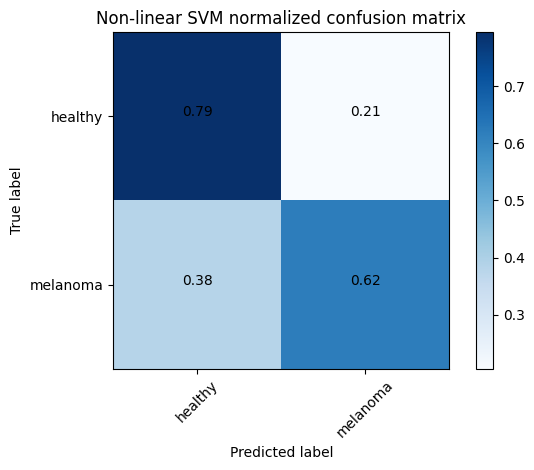

In [38]:
# Fitting Non-linear SVM
print("Fitting Non-linear SVM to the training set")
NLsvm = make_pipeline2(ADASYN(random_state=0),StandardScaler(), SVC(kernel='rbf'))
p_grid_nlsvm = {'svc__C': [1e-3,1e-2,1e-1,1,2,3,4,5,6,7,8,9,1e1],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1]}
grid_nlsvm = GridSearchCV(estimator=NLsvm, param_grid=p_grid_nlsvm, scoring='f1', cv=5)
grid_nlsvm.fit(X_train, y_train)
print("Best training Score: {}".format(grid_nlsvm.best_score_))
print("Best training params: {}".format(grid_nlsvm.best_params_))
y_pred = grid_nlsvm.predict(X_test)
print(classification_report(y_test, y_pred))
cnf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Non-linear SVM normalized confusion matrix')
plt.show()


Using the non-linear SVM with alternative scoring and with oversampled training data often changes the selected hyperparameters and the class balance of predictions. When the model is optimized with F1 instead of accuracy, it generally accepts a few more false positives in exchange for better melanoma recall. This shift is expected in imbalanced classification and usually aligns better with the medical objective of reducing missed malignant lesions.


Across the different experiments, linear and non-linear SVM models are usually the most reliable choices once scaling and cross-validation are applied correctly. The key methodological point is that accuracy alone can be misleading on this dataset, so F1 is a better primary score for model selection. Oversampling the melanoma class is generally worthwhile because it improves sensitivity to malignant cases, even if the gain in global accuracy is modest. In a screening scenario, this trade-off is typically preferable because it reduces the risk of false reassurance on true melanoma images.


**OPTIONAL** Another interesting question is: what about the number of features ? Can we reduce the dimensionality ? You could use one of the techniques seen during the previous lectures (i.e. PCA) ...

In [39]:
# Test PCA with a linear SVM
from sklearn.model_selection import cross_val_score

Lsvm = make_pipeline2(ADASYN(random_state=0),StandardScaler(), PCA(n_components=0.95), LinearSVC())
p_grid_lsvm = {'linearsvc__C': [1e-3,1e-2,1e-1,1,2,3,4,5,6,7,8,9,1e1]}

grid_lsvm_pca = GridSearchCV(estimator=Lsvm, param_grid=p_grid_lsvm, scoring='f1', cv=5)
grid_lsvm_pca.fit(X_train, y_train)
print("Best training Score with PCA: {}".format(grid_lsvm_pca.best_score_))
print("Best params with PCA: {}".format(grid_lsvm_pca.best_params_))
y_pred = grid_lsvm_pca.predict(X_test)
print(classification_report(y_test, y_pred))


Best training Score with PCA: 0.45681748556616003
Best params with PCA: {'linearsvc__C': 0.001}
              precision    recall  f1-score   support

           0       0.89      0.75      0.81       146
           1       0.36      0.59      0.44        34

    accuracy                           0.72       180
   macro avg       0.62      0.67      0.63       180
weighted avg       0.79      0.72      0.74       180



**OPTIONAL** ... or test the importance of the single features.
The more naive technique would be to test each feature independently in a greedy fashion called sequential forward feature selection. Starting from an empty set and a classification model, you will first add the feature that maximizes a certain criterion (i.e. f1 score). Then, you will iterate this process until a chosen stopping criterion by adding at each iteration only the best feature. Each feature can be added of course only once. You could also use the opposite process by removing at each iteraton the least important feature starting from the entire set of features (i.e. sequential backward feature selection). Implement at least one of these ideas.

In [40]:
# Implement forward feature selection and/or backward feature selection
# with a linear SVM
from sklearn.feature_selection import SequentialFeatureSelector

base_estimator = make_pipeline(StandardScaler(), LinearSVC(C=1, max_iter=5000))
sfs = SequentialFeatureSelector(base_estimator, n_features_to_select=10, direction='forward', scoring='f1', cv=5, n_jobs=-1)
sfs.fit(X_train, y_train)
selected_features = np.where(sfs.get_support())[0]
print("Selected feature indices:", selected_features)

X_train_sel = X_train[:, selected_features]
X_test_sel = X_test[:, selected_features]

final_model = make_pipeline2(ADASYN(random_state=0), StandardScaler(), LinearSVC(C=1, max_iter=5000))
final_model.fit(X_train_sel, y_train)
y_pred = final_model.predict(X_test_sel)
print(classification_report(y_test, y_pred))


Selected feature indices: [ 0  2  6  7  8  9 19 21 28 29]
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       146
           1       0.42      0.56      0.48        34

    accuracy                           0.77       180
   macro avg       0.66      0.69      0.67       180
weighted avg       0.80      0.77      0.78       180

